# Graphs 4 & 5 — Standalone

**Graph 4:** Heatmap showing regional temperature intensity over time (latitude × year)  
**Graph 5:** Scatterplot comparing greenhouse gas (CO₂) concentration and temperature change

In [1]:
import ssl
import numpy as np
import pandas as pd
import xarray as xr
import zarr
import gcsfs
import matplotlib.pyplot as plt

ssl._create_default_https_context = ssl._create_unverified_context
xr.set_options(display_style='html')
plt.rcParams['figure.figsize'] = 12, 6
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# Load CMIP6 catalog
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')

# Open CESM2 historical surface air temperature
gcs = gcsfs.GCSFileSystem(token='anon')
df_ta_ncar = df.query(
    "activity_id=='CMIP' & table_id=='Amon' & variable_id=='tas' "
    "& experiment_id=='historical' & institution_id=='NCAR' & source_id=='CESM2'"
)
zstore = df_ta_ncar.query("member_id=='r1i1p1f1'").zstore.values[0]
ds = xr.open_zarr(gcs.get_mapper(zstore), consolidated=True)

# Area weights for global mean
df_area = df.query("variable_id=='areacella' & source_id=='CESM2'")
ds_area = xr.open_zarr(gcs.get_mapper(df_area.zstore.values[0]), consolidated=True)

total_area = ds_area.areacella.sum(dim=['lon', 'lat'])
ta_timeseries = (ds.tas * ds_area.areacella).sum(dim=['lon', 'lat']) / total_area
ta_timeseries.load()

I0505 23:01:27.594467 33467738 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0505 23:01:27.619304 33467753 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(94, generation: 1)
I0505 23:01:27.619598 33467753 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(94, generation: 1)
I0505 23:01:27.619603 33467753 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(94, generation: 1)
I0505 23:01:27.619606 33467753 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(94, generation: 1)
I0505 23:01:27.619611 33467753 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(94, generation: 1)
I0505 23:01:27.619618 33467753 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(94, generation: 1)
I0505 23:01:27.619620 33467753 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(94, generation: 1)
I0505 23:01:27.619622 33467753 ev_poll_posix.cc:593] FD from fork parent s

<xarray.DataArray (time: 1980)> Size: 8kB
array([285.2367 , 285.49353, 286.10147, ..., 288.3483 , 287.31396,
       286.56613], dtype=float32)
Coordinates:
  * time     (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
Attributes: (12/19)
    cell_measures:  area: areacella
    time:           time
    type:           real
    cell_methods:   area: sum
    comment:        Cell areas for any grid used to report atmospheric variab...
    description:    Cell areas for any grid used to report atmospheric variab...
    ...             ...
    standard_name:  cell_area
    time_label:     None
    time_title:     No temporal dimensions ... fixed field
    title:          Grid-Cell Area for Atmospheric Grid Variables
    units:          m2
    variable_id:    areacella

## Graph 4 — Heatmap: Regional Temperature Intensity Over Time

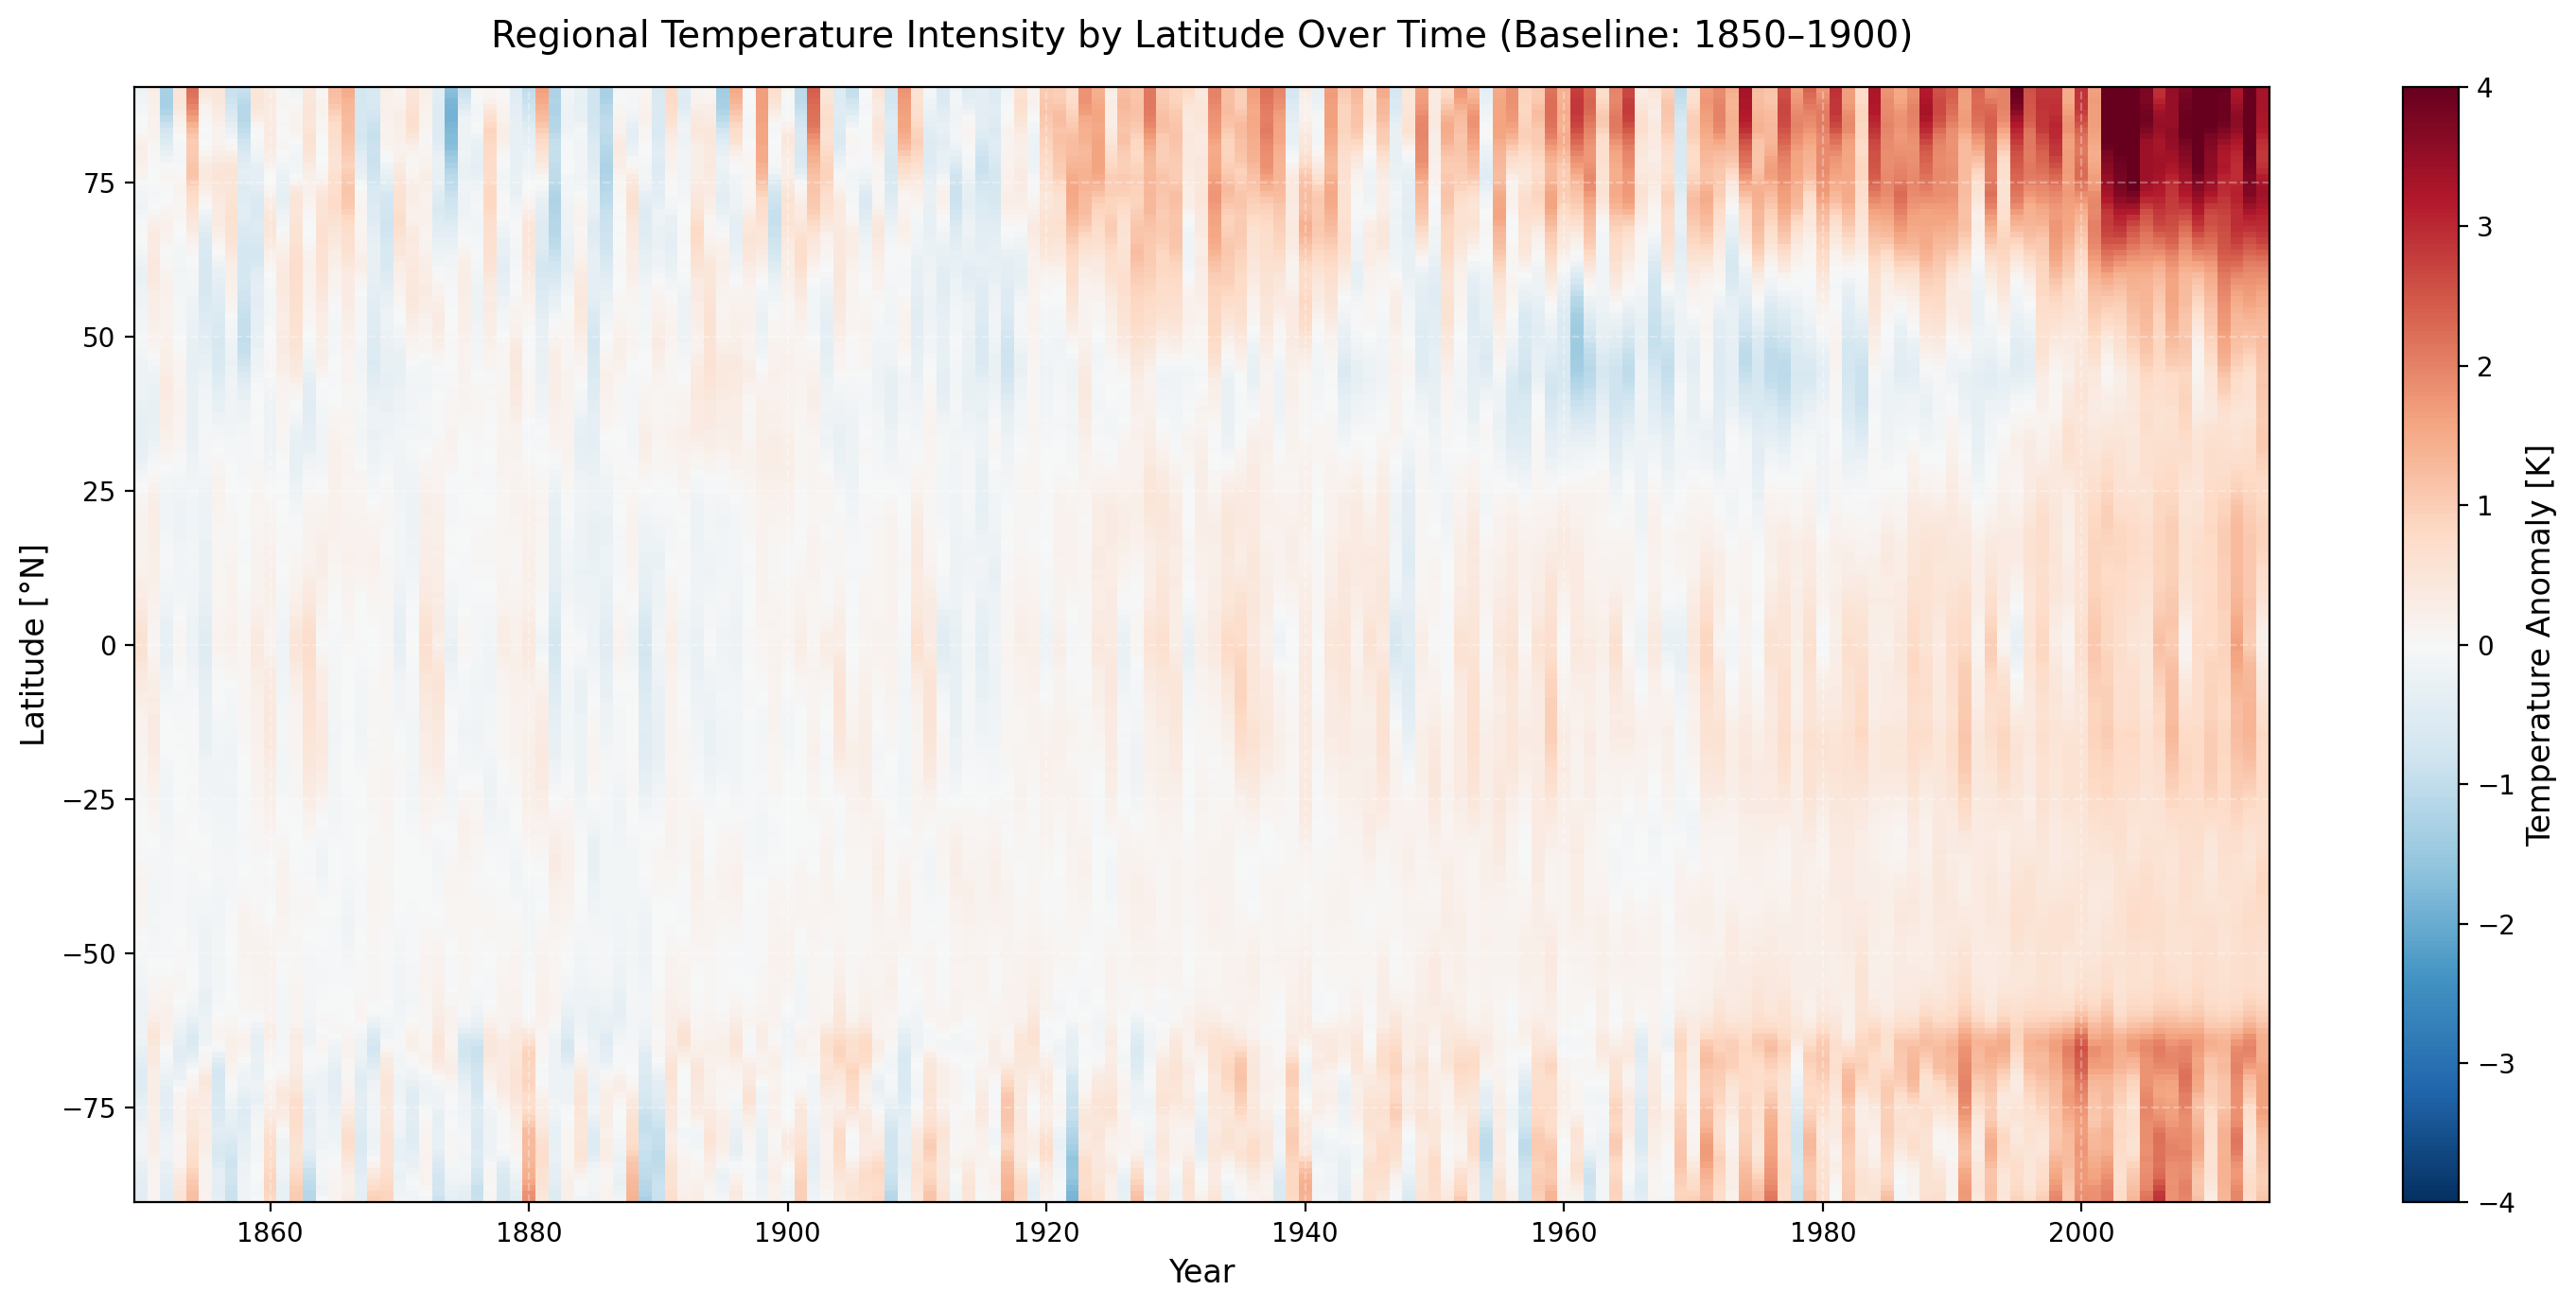

In [3]:
# Zonal mean: average over all longitudes → shape (time, lat)
zonal_mean = ds.tas.mean(dim='lon')
baseline_zonal = zonal_mean.sel(time=slice('1850', '1900')).mean(dim='time')
zonal_anomaly = zonal_mean - baseline_zonal

# Resample to annual means for a cleaner plot
zonal_annual = zonal_anomaly.resample(time='YE').mean()
zonal_annual.load()

fig, ax = plt.subplots(figsize=(15, 7))

im = ax.pcolormesh(
    zonal_annual.time.dt.year.values,
    zonal_annual.lat.values,
    zonal_annual.values.T,
    cmap='RdBu_r',
    vmin=-4, vmax=4
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Temperature Anomaly [K]', fontsize=12)

ax.set_title('Regional Temperature Intensity by Latitude Over Time (Baseline: 1850–1900)', fontsize=14, pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Latitude [°N]', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3, color='white')

plt.tight_layout()
plt.show()

## Graph 5 — Scatterplot: CO₂ Concentration vs. Temperature Change

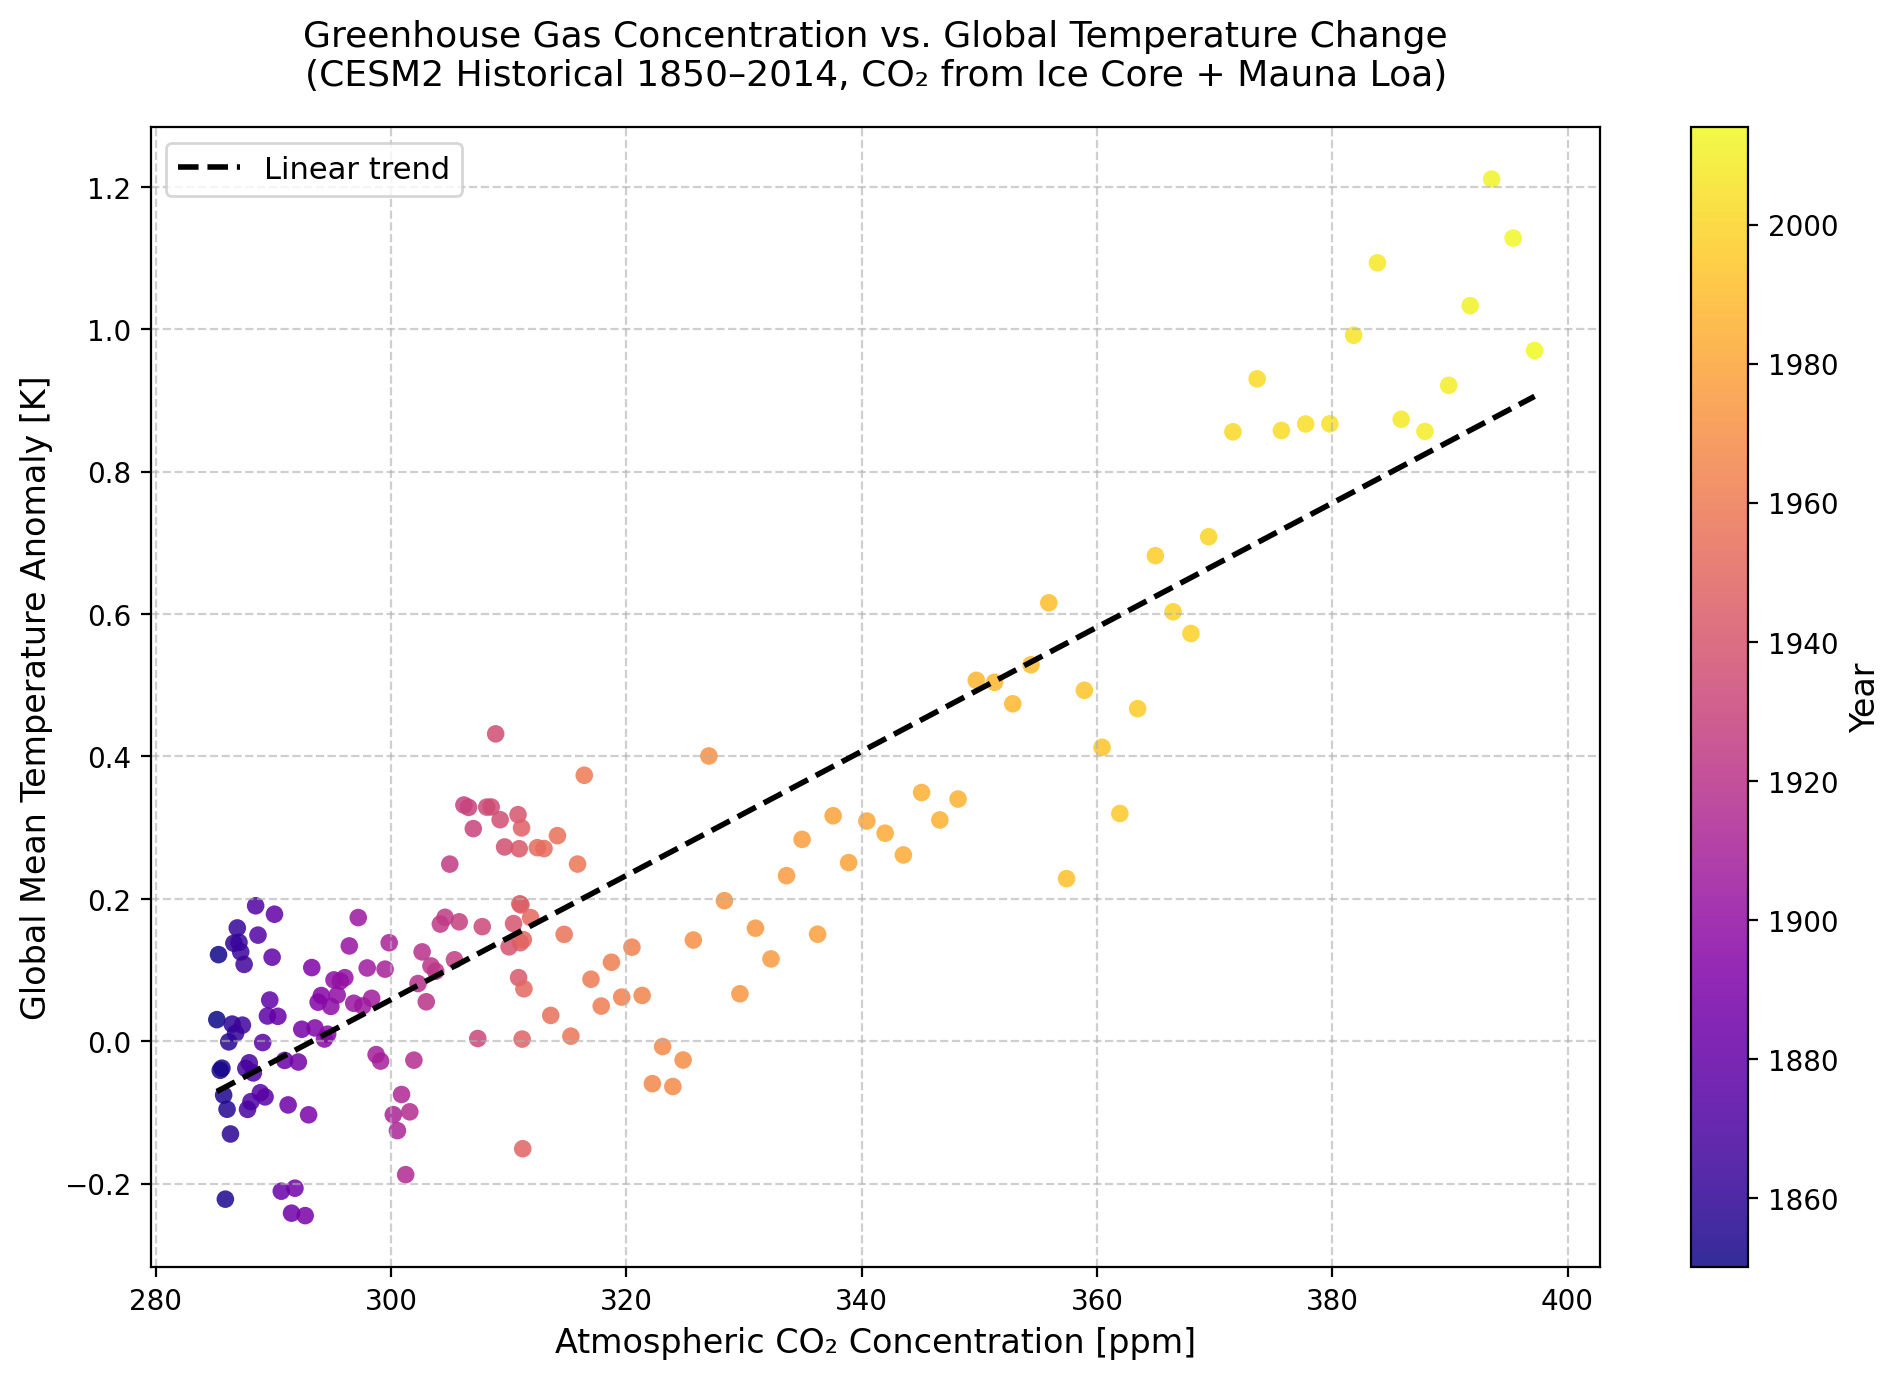

In [4]:
# Historical CO₂ concentrations (ppm) — ice core + Mauna Loa records (IPCC AR6)
co2_anchor_years = np.array([1850, 1870, 1880, 1890, 1900, 1910, 1920, 1930,
                              1940, 1950, 1960, 1970, 1980, 1990, 2000, 2005, 2010, 2014])
co2_anchor_ppm   = np.array([285.2, 288.1, 290.1, 293.0, 295.7, 299.5, 303.0, 307.0,
                              310.8, 311.3, 317.0, 325.7, 338.9, 354.4, 369.5, 379.8, 389.9, 397.2])

all_years = np.arange(1850, 2015)
co2_annual_ppm = np.interp(all_years, co2_anchor_years, co2_anchor_ppm)

# Annual mean temperature anomaly
ta_annual = ta_timeseries.resample(time='YE').mean()
baseline_annual = ta_annual.sel(time=slice('1850', '1900')).mean()
ta_anomaly_annual = (ta_annual - baseline_annual).values  # 165 values, 1850–2014

fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(co2_annual_ppm, ta_anomaly_annual, c=all_years,
                cmap='plasma', s=40, alpha=0.85, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Year', fontsize=12)

z = np.polyfit(co2_annual_ppm, ta_anomaly_annual, 1)
p = np.poly1d(z)
x_line = np.linspace(co2_annual_ppm.min(), co2_annual_ppm.max(), 200)
ax.plot(x_line, p(x_line), color='black', linewidth=2, linestyle='--', label='Linear trend')

ax.set_title('Greenhouse Gas Concentration vs. Global Temperature Change\n'
             '(CESM2 Historical 1850–2014, CO₂ from Ice Core + Mauna Loa)', fontsize=13, pad=15)
ax.set_xlabel('Atmospheric CO₂ Concentration [ppm]', fontsize=12)
ax.set_ylabel('Global Mean Temperature Anomaly [K]', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()